In [ ]:
# Run this only if a dependency is missing.
# %pip install -U --no-cache-dir gdown tabicl scikit-image scipy matplotlib numpy pandas scikit-learn


In [1]:
import os
import json
import tarfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from scipy.optimize import brentq
from sklearn.isotonic import IsotonicRegression
from skimage.transform import rescale, resize
from tabicl import TabICLRegressor

B_LOSS = 1.0


In [2]:
import gdown

# Load the cached tumor-segmentation data and PraNet probabilities.
# The .npz file is about 3.4 GB, so this cell can take a while.
# This works whether the notebook cwd is the repo root or Synthetic/.
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == 'Synthetic' else cwd
data_dir = project_root / 'data'
archive_path = project_root / 'data.tar.gz'
npz_path = data_dir / 'polyps' / 'polyps-pranet.npz'

if not npz_path.exists():
    if not archive_path.exists():
        print('Downloading tumor-segmentation data archive...')
        gdown.download(id='1h7S6N_Rx7gdfO3ZunzErZy6H7620EbZK', output=str(archive_path), quiet=False)
    print('Extracting tumor-segmentation data archive...')
    with tarfile.open(archive_path, 'r:gz') as archive:
        archive.extractall(project_root)
    
print(f'Opening {npz_path}...')
data = np.load(npz_path)
example_paths = os.listdir(data_dir / 'polyps' / 'examples')

print('Loading probability maps and ground-truth masks into memory...')
probabilities = data['sgmd']       # PraNet sigmoid probabilities, shape: (1798, 352, 352)
gt_masks = data['targets']         # Ground-truth binary masks, shape: (1798, 352, 352)
example_indexes = data['example_indexes']

# Keep the original variable name from the upstream notebook too.
sgmd = probabilities
print('Loaded:', probabilities.shape, gt_masks.shape)

Opening /home/bresende/projects/pesquisa/CRC_rectification/data/polyps/polyps-pranet.npz...
Loading probability maps and ground-truth masks into memory...
Loaded: (1798, 352, 352) (1798, 352, 352)


In [3]:
# Problem setup
n = 800  # number of calibration points
alpha = 0.1  # desired false-negative risk level

# Split the PraNet probability maps into calibration and validation sets.
rng_split = np.random.default_rng(2026)
all_indexes = np.arange(sgmd.shape[0])
cal_indexes = rng_split.choice(all_indexes, size=n, replace=False)
val_indexes = np.setdiff1d(all_indexes, cal_indexes)

cal_sgmd, val_sgmd = sgmd[cal_indexes], sgmd[val_indexes]
cal_gt_masks, val_gt_masks = gt_masks[cal_indexes], gt_masks[val_indexes]

print("calibration/validation sizes:", len(cal_indexes), len(val_indexes))


calibration/validation sizes: 800 998


In [4]:
# Route 2 first part: summarize each image by probability quantiles.
N_QUANTILES = 90
quantile_levels = np.linspace(0.0, 1.0, N_QUANTILES)
quantile_columns = [f"prob_q_{level:.3f}" for level in quantile_levels]

probability_quantiles = np.empty((probabilities.shape[0], N_QUANTILES), dtype=float)
for i, prob_map in enumerate(probabilities):
    if i % 100 == 0:
        print(f'Computing quantiles: {i}/{probabilities.shape[0]}')
    probability_quantiles[i] = np.quantile(prob_map.reshape(-1), quantile_levels)

X_quantiles = pd.DataFrame(probability_quantiles, columns=quantile_columns)
X_quantiles.head()

Computing quantiles: 0/1798
Computing quantiles: 100/1798
Computing quantiles: 200/1798
Computing quantiles: 300/1798
Computing quantiles: 400/1798
Computing quantiles: 500/1798
Computing quantiles: 600/1798
Computing quantiles: 700/1798
Computing quantiles: 800/1798
Computing quantiles: 900/1798
Computing quantiles: 1000/1798
Computing quantiles: 1100/1798
Computing quantiles: 1200/1798
Computing quantiles: 1300/1798
Computing quantiles: 1400/1798
Computing quantiles: 1500/1798
Computing quantiles: 1600/1798
Computing quantiles: 1700/1798


,prob_q_0.000,prob_q_0.011,prob_q_0.022,prob_q_0.034,prob_q_0.045,prob_q_0.056,prob_q_0.067,prob_q_0.079,prob_q_0.090,prob_q_0.101,...,prob_q_0.899,prob_q_0.910,prob_q_0.921,prob_q_0.933,prob_q_0.944,prob_q_0.955,prob_q_0.966,prob_q_0.978,prob_q_0.989,prob_q_1.000
0,0.050792,0.073191,0.081550,0.092657,0.106634,0.121850,0.136465,0.148961,0.160722,0.170434,...,0.933368,0.940079,0.946691,0.952015,0.956770,0.964139,0.969930,0.976229,0.984852,0.993642
1,0.045520,0.078742,0.096350,0.108779,0.115703,0.122693,0.129104,0.136347,0.143960,0.151150,...,0.961271,0.965899,0.969553,0.973213,0.977297,0.980947,0.984069,0.986506,0.988758,0.991239
2,0.019697,0.044503,0.058211,0.068318,0.077653,0.086320,0.095590,0.105390,0.115517,0.125297,...,0.949570,0.954652,0.959128,0.962979,0.966165,0.969282,0.972605,0.976466,0.982414,0.992084
3,0.020888,0.044716,0.078553,0.105011,0.118950,0.127722,0.135111,0.141866,0.148176,0.155107,...,0.606314,0.706422,0.772786,0.814167,0.847059,0.875353,0.898734,0.917679,0.949707,0.984163
4,0.009730,0.028659,0.039962,0.052520,0.060882,0.070393,0.081713,0.093708,0.106477,0.118845,...,0.289514,0.298833,0.410957,0.599275,0.774825,0.886929,0.952223,0.983485,0.995391,0.999208


In [5]:
def segmentation_mask(probability_maps, lam):
    """
    Protective-lambda convention:
        C_lambda(x) = {pixels: p(pixel) >= 1 - lambda}.

    This is equivalent to the PDF threshold convention with
        threshold = 1 - lambda.

    Larger lambda lowers the threshold, gives a larger predicted mask,
    and therefore produces lower or equal false-negative risk.
    """
    lam = np.asarray(lam)
    if lam.ndim == 1:
        lam = lam[:, None, None]
    threshold = 1.0 - lam
    return probability_maps >= threshold


def false_negative_rate(probability_maps, true_masks, lam):
    """
    Per-image false negative rate:
        missed true tumor pixels / true tumor pixels.
    """
    pred_masks = segmentation_mask(probability_maps, lam)
    true_masks_bool = true_masks.astype(bool)

    n_positive = true_masks_bool.reshape(true_masks_bool.shape[0], -1).sum(axis=1)
    missed_positive = (true_masks_bool & ~pred_masks).reshape(true_masks_bool.shape[0], -1).sum(axis=1)

    return np.divide(
        missed_positive,
        n_positive,
        out=np.zeros_like(missed_positive, dtype=float),
        where=n_positive > 0,
    )


def build_route2_augmented_dataset(probability_maps, true_masks, image_features, K_aug=20, rng=None):
    """
    Build Route 2 augmented data:
        (90 probability quantiles, lambda) -> false negative rate.

    For each image, draw K_aug lambdas independently from Uniform(0, 1).
    """
    if rng is None:
        rng = np.random.default_rng()

    n_images = probability_maps.shape[0]
    lambda_draws = rng.uniform(0.0, 1.0, size=(n_images, K_aug))

    X_rep = np.repeat(image_features.to_numpy(), K_aug, axis=0)
    lambda_rep = lambda_draws.reshape(-1)

    losses = np.empty(n_images * K_aug, dtype=float)
    for k in range(K_aug):
        losses[k::K_aug] = false_negative_rate(
            probability_maps,
            true_masks,
            lambda_draws[:, k][:, None, None],
        )

    X_aug = pd.DataFrame(X_rep, columns=image_features.columns)
    X_aug["lambda"] = lambda_rep

    y_aug = pd.Series(losses, name="false_negative_rate")

    return X_aug, y_aug, lambda_draws


def inverter_R(R_row, lambda_grid, a):
    """inf {lambda in grid: estimated R(lambda | x) <= a}."""
    mask = R_row <= a
    if not mask.any():
        return float(lambda_grid[-1])
    return float(lambda_grid[np.argmax(mask)])


def lambdas_from_risk_matrix(R_mat, lambda_grid, a):
    """Apply inverter_R row-by-row to get one lambda per image."""
    return np.array([inverter_R(row, lambda_grid, a) for row in R_mat], dtype=float)


def calibrar_crc(losses_cal, lambda_grid, alpha, B=B_LOSS):
    """Standard CRC: smallest global lambda with corrected risk <= alpha."""
    n = losses_cal.shape[0]
    R_cal = losses_cal.mean(axis=0)
    R_upper = (n * R_cal + B) / (n + 1)
    mask = R_upper <= alpha
    if not mask.any():
        return float(lambda_grid[-1])
    return float(lambda_grid[np.argmax(mask)])


def calibrar_crc_rectified(losses_rect, a_grid, alpha, B=B_LOSS):
    """Rectified CRC: largest risk budget a with corrected risk <= alpha."""
    n = losses_rect.shape[0]
    R_cal = losses_rect.mean(axis=0)
    R_upper = (n * R_cal + B) / (n + 1)
    mask = R_upper <= alpha
    if not mask.any():
        return float(a_grid[0])
    return float(a_grid[np.where(mask)[0].max()])


def fit_risk_surface_tabicl(probability_maps, true_masks, image_features, K_aug=15,
                            device="cuda", rng=None):
    """Fit TabICL to estimate the conditional risk surface."""
    X_aug, y_aug, _ = build_route2_augmented_dataset(
        probability_maps,
        true_masks,
        image_features,
        K_aug=K_aug,
        rng=rng,
    )
    reg = TabICLRegressor(device=device, kv_cache=True, random_state=42)
    reg.fit(X_aug, y_aug)
    return reg


def estimate_R_route2(reg_surface, image_features, lambda_grid):
    """
    Estimate R(lambda | x) on a grid of lambda values using TabICL.

    Returns an n x L matrix and enforces nonincreasing risk in lambda
    by reverse isotonic regression for each queried x.
    """
    if isinstance(image_features, pd.DataFrame):
        X_base = image_features.reset_index(drop=True).copy()
    else:
        X_base = pd.DataFrame(np.asarray(image_features))

    n = len(X_base)
    L = len(lambda_grid)
    R_hat = np.empty((n, L))

    for j, lam in enumerate(lambda_grid):
        X_query = X_base.copy()
        X_query["lambda"] = lam
        R_hat[:, j] = reg_surface.predict(X_query)

    R_hat = np.clip(R_hat, 0.0, B_LOSS)

    for i in range(n):
        iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
        neg_R_iso = iso.fit_transform(lambda_grid, -R_hat[i])
        R_hat[i] = np.clip(-neg_R_iso, 0.0, B_LOSS)

    return R_hat


def losses_over_lambda_segmentation(probability_maps, true_masks, lambda_grid):
    """Calibration/test FNR matrix with shape n_images x len(lambda_grid)."""
    losses = np.empty((probability_maps.shape[0], len(lambda_grid)), dtype=float)
    for j, lam in enumerate(lambda_grid):
        losses[:, j] = false_negative_rate(probability_maps, true_masks, lam)
    return losses


def calibrate_rectified_segmentation(probability_maps_cal, true_masks_cal,
                                     R_cal_mat, lambda_grid, a_grid,
                                     alpha, B=B_LOSS):
    """
    Choose a_hat using the calibration images.

    For each candidate a, invert each calibration image's estimated risk curve
    to get lambda_i(a), compute the true calibration FNR at that lambda_i(a),
    and apply the CRC finite-sample correction.
    """
    losses_rect = np.empty((probability_maps_cal.shape[0], len(a_grid)), dtype=float)

    for j, a in enumerate(a_grid):
        lambda_cal = lambdas_from_risk_matrix(R_cal_mat, lambda_grid, a)
        losses_rect[:, j] = false_negative_rate(
            probability_maps_cal,
            true_masks_cal,
            lambda_cal,
        )

    a_hat = calibrar_crc_rectified(losses_rect, a_grid, alpha, B=B)
    n = losses_rect.shape[0]
    risk = losses_rect.mean(axis=0)
    risk_upper = (n * risk + B) / (n + 1)
    calibration_curve = pd.DataFrame({
        "a": a_grid,
        "risk": risk,
        "risk_upper": risk_upper,
    })

    return a_hat, losses_rect, calibration_curve


def rectified_lambdas_and_masks(reg_surface, image_features, probability_maps,
                                lambda_grid, a_hat):
    """Estimate R(lambda | x), invert at a_hat, and return masks."""
    R_mat = estimate_R_route2(reg_surface, image_features, lambda_grid)
    lambda_vec = lambdas_from_risk_matrix(R_mat, lambda_grid, a_hat)
    masks = segmentation_mask(probability_maps, lambda_vec)
    return lambda_vec, masks, R_mat


def fit_calibrate_rectified_route2_segmentation(
    probability_maps_context,
    true_masks_context,
    features_context,
    probability_maps_cal,
    true_masks_cal,
    features_cal,
    probability_maps_target,
    features_target,
    alpha=0.10,
    lambda_grid=None,
    a_grid=None,
    K_aug=20,
    device="cuda",
    rng=None,
):
    """
    Full segmentation Route 2 pipeline:
      1. fit TabICL risk surface on context images;
      2. estimate R(lambda | x) on calibration images;
      3. calibrate a_hat by rectified CRC;
      4. estimate one lambda per target image and create masks.
    """
    if lambda_grid is None:
        lambda_grid = np.linspace(0.0, 1.0, 51)
    if a_grid is None:
        a_grid = np.linspace(0.001, 1.0, 50)

    reg_surface = fit_risk_surface_tabicl(
        probability_maps_context,
        true_masks_context,
        features_context,
        K_aug=K_aug,
        device=device,
        rng=rng,
    )

    R_cal_mat = estimate_R_route2(reg_surface, features_cal, lambda_grid)
    a_hat, losses_rect_cal, calibration_curve = calibrate_rectified_segmentation(
        probability_maps_cal,
        true_masks_cal,
        R_cal_mat,
        lambda_grid,
        a_grid,
        alpha,
        B=B_LOSS,
    )

    lambda_target, target_masks, R_target_mat = rectified_lambdas_and_masks(
        reg_surface,
        features_target,
        probability_maps_target,
        lambda_grid,
        a_hat,
    )

    return {
        "reg_surface": reg_surface,
        "a_hat": a_hat,
        "lambda_target": lambda_target,
        "target_masks": target_masks,
        "R_cal_mat": R_cal_mat,
        "R_target_mat": R_target_mat,
        "losses_rect_cal": losses_rect_cal,
        "calibration_curve": calibration_curve,
        "lambda_grid": lambda_grid,
        "a_grid": a_grid,
    }

In [6]:
rng = np.random.default_rng(2026)

X_aug, y_aug, lambda_draws = build_route2_augmented_dataset(
    probability_maps=cal_sgmd,
    true_masks=cal_gt_masks,
    image_features=X_quantiles.iloc[cal_indexes].reset_index(drop=True),
    K_aug=20,
    rng=rng,
)

print("10 lambda draws for the first calibration image:")
print(np.round(lambda_draws[0], 4))
print("X_aug shape:", X_aug.shape)
print("y_aug shape:", y_aug.shape)

display(X_aug.head())
display(y_aug.head())


10 lambda draws for the first calibration image:
[0.1789 0.6399 0.4673 0.3705 0.3549 0.7905 0.9051 0.1774 0.6528 0.2983
 0.967  0.9199 0.6359 0.7527 0.5152 0.8259 0.4484 0.3388 0.2779 0.2263]
X_aug shape: (16000, 91)
y_aug shape: (16000,)


,prob_q_0.000,prob_q_0.011,prob_q_0.022,prob_q_0.034,prob_q_0.045,prob_q_0.056,prob_q_0.067,prob_q_0.079,prob_q_0.090,prob_q_0.101,...,prob_q_0.910,prob_q_0.921,prob_q_0.933,prob_q_0.944,prob_q_0.955,prob_q_0.966,prob_q_0.978,prob_q_0.989,prob_q_1.000,lambda
0,0.035277,0.097413,0.136401,0.158766,0.172611,0.189032,0.206892,0.224654,0.23848,0.251693,...,0.948363,0.951199,0.954221,0.956964,0.95913,0.961965,0.965784,0.972029,0.978975,0.178935
1,0.035277,0.097413,0.136401,0.158766,0.172611,0.189032,0.206892,0.224654,0.23848,0.251693,...,0.948363,0.951199,0.954221,0.956964,0.95913,0.961965,0.965784,0.972029,0.978975,0.639913
2,0.035277,0.097413,0.136401,0.158766,0.172611,0.189032,0.206892,0.224654,0.23848,0.251693,...,0.948363,0.951199,0.954221,0.956964,0.95913,0.961965,0.965784,0.972029,0.978975,0.467268
3,0.035277,0.097413,0.136401,0.158766,0.172611,0.189032,0.206892,0.224654,0.23848,0.251693,...,0.948363,0.951199,0.954221,0.956964,0.95913,0.961965,0.965784,0.972029,0.978975,0.370501
4,0.035277,0.097413,0.136401,0.158766,0.172611,0.189032,0.206892,0.224654,0.23848,0.251693,...,0.948363,0.951199,0.954221,0.956964,0.95913,0.961965,0.965784,0.972029,0.978975,0.354917


0    0.409073
1    0.000265
2    0.029695
3    0.086099
4    0.100932
Name: false_negative_rate, dtype: float64

In [7]:
import time
import torch

# Calibrate both methods on the calibration set only, then compare on validation.
ALPHA = alpha
K_AUG = 20
lambda_grid = np.linspace(0.0, 1.0, 51)
a_grid = np.linspace(0.001, 1.0, 50)

rng_route2 = np.random.default_rng(2026)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("TabICL device:", device)
print("calibration/validation sizes:", len(cal_indexes), len(val_indexes))

features_cal = X_quantiles.iloc[cal_indexes].reset_index(drop=True)
features_val = X_quantiles.iloc[val_indexes].reset_index(drop=True)

t0 = time.time()

# ====== Usual CRC: choose one global lambda on calibration ======
losses_cal_by_lambda = losses_over_lambda_segmentation(cal_sgmd, cal_gt_masks, lambda_grid)
lambda_crc = calibrar_crc(losses_cal_by_lambda, lambda_grid, ALPHA, B=B_LOSS)

crc_cal_losses = false_negative_rate(cal_sgmd, cal_gt_masks, lambda_crc)
crc_val_losses = false_negative_rate(val_sgmd, val_gt_masks, lambda_crc)
crc_val_masks = segmentation_mask(val_sgmd, lambda_crc)

# ====== Rectified CRC: fit Route 2 risk surface and calibrate a on calibration ======
reg_surface = fit_risk_surface_tabicl(
    probability_maps=cal_sgmd,
    true_masks=cal_gt_masks,
    image_features=features_cal,
    K_aug=K_AUG,
    device=device,
    rng=rng_route2,
)

R_cal_mat = estimate_R_route2(reg_surface, features_cal, lambda_grid)
a_hat, losses_rect_cal, rect_calibration_curve = calibrate_rectified_segmentation(
    probability_maps_cal=cal_sgmd,
    true_masks_cal=cal_gt_masks,
    R_cal_mat=R_cal_mat,
    lambda_grid=lambda_grid,
    a_grid=a_grid,
    alpha=ALPHA,
    B=B_LOSS,
)

lambda_cal_rect = lambdas_from_risk_matrix(R_cal_mat, lambda_grid, a_hat)
rect_cal_losses = false_negative_rate(cal_sgmd, cal_gt_masks, lambda_cal_rect)

lambda_val_rect, rect_val_masks, R_val_mat = rectified_lambdas_and_masks(
    reg_surface=reg_surface,
    image_features=features_val,
    probability_maps=val_sgmd,
    lambda_grid=lambda_grid,
    a_hat=a_hat,
)
rect_val_losses = false_negative_rate(val_sgmd, val_gt_masks, lambda_val_rect)

# Keep the previous output shape/names useful for downstream visualization cells.
lambda_by_image_index = np.full(probabilities.shape[0], np.nan, dtype=float)
lambda_by_image_index[cal_indexes] = lambda_cal_rect
lambda_by_image_index[val_indexes] = lambda_val_rect
predicted_masks_by_validation = rect_val_masks

n_cal = len(cal_indexes)
crc_cal_risk_upper = (n_cal * crc_cal_losses.mean() + B_LOSS) / (n_cal + 1)
rect_cal_risk_upper = (n_cal * rect_cal_losses.mean() + B_LOSS) / (n_cal + 1)

comparison = pd.DataFrame([
    {
        "method": "Standard CRC",
        "calibration_risk": crc_cal_losses.mean(),
        "calibration_risk_upper": crc_cal_risk_upper,
        "validation_risk": crc_val_losses.mean(),
        "validation_mask_fraction": crc_val_masks.reshape(crc_val_masks.shape[0], -1).mean(axis=1).mean(),
        "lambda_mean": lambda_crc,
        "lambda_median": lambda_crc,
    },
    {
        "method": "Rectified CRC",
        "calibration_risk": rect_cal_losses.mean(),
        "calibration_risk_upper": rect_cal_risk_upper,
        "validation_risk": rect_val_losses.mean(),
        "validation_mask_fraction": rect_val_masks.reshape(rect_val_masks.shape[0], -1).mean(axis=1).mean(),
        "lambda_mean": lambda_val_rect.mean(),
        "lambda_median": np.median(lambda_val_rect),
    },
])

route2_out = {
    "reg_surface": reg_surface,
    "a_hat": a_hat,
    "lambda_cal": lambda_cal_rect,
    "lambda_val": lambda_val_rect,
    "val_masks": rect_val_masks,
    "R_cal_mat": R_cal_mat,
    "R_val_mat": R_val_mat,
    "losses_rect_cal": losses_rect_cal,
    "calibration_curve": rect_calibration_curve,
    "lambda_grid": lambda_grid,
    "a_grid": a_grid,
    "standard_lambda": lambda_crc,
    "comparison": comparison,
}

print(f"finished in {time.time() - t0:.1f}s")
print("Standard CRC lambda:", lambda_crc)
print("Rectified CRC a_hat:", a_hat)
display(comparison)
display(rect_calibration_curve.head())


TabICL device: cuda
calibration/validation sizes: 800 998
finished in 34.2s
Standard CRC lambda: 0.54
Rectified CRC a_hat: 0.10293877551020408


,method,calibration_risk,calibration_risk_upper,validation_risk,validation_mask_fraction,lambda_mean,lambda_median
0,Standard CRC,0.098046,0.099172,0.110335,0.115017,0.540000,0.54
1,Rectified CRC,0.091420,0.092554,0.091091,0.187744,0.429679,0.38


,a,risk,risk_upper
0,0.001000,0.000449,0.001697
1,0.021388,0.017593,0.018820
2,0.041776,0.035283,0.036487
3,0.062163,0.054732,0.055912
4,0.082551,0.073138,0.074295


In [8]:
# Local validation diagnostics for Standard CRC vs Rectified CRC.
# This evaluates whether rectification keeps marginal/pixel-wise coverage while adapting
# lambda and region size across image difficulty bins.

def mask_metrics_dataframe(method, predicted_masks, true_masks, lambdas, probability_maps):
    predicted_bool = predicted_masks.astype(bool)
    true_bool = true_masks.astype(bool)

    pred_area = predicted_bool.reshape(predicted_bool.shape[0], -1).sum(axis=1).astype(float)
    true_area = true_bool.reshape(true_bool.shape[0], -1).sum(axis=1).astype(float)
    missed_area = (true_bool & ~predicted_bool).reshape(true_bool.shape[0], -1).sum(axis=1).astype(float)

    fnr = np.divide(
        missed_area,
        true_area,
        out=np.zeros_like(missed_area, dtype=float),
        where=true_area > 0,
    )
    exact_coverage = (missed_area == 0).astype(float)
    pixelwise_coverage = 1.0 - fnr
    efficiency_y_over_c = np.divide(
        true_area,
        pred_area,
        out=np.zeros_like(true_area, dtype=float),
        where=pred_area > 0,
    )

    flat_probs = probability_maps.reshape(probability_maps.shape[0], -1)
    uncertainty = 1.0 - 2.0 * np.abs(flat_probs - 0.5)

    return pd.DataFrame({
        "method": method,
        "lambda": np.asarray(lambdas, dtype=float),
        "exact_coverage": exact_coverage,
        "pixelwise_coverage": pixelwise_coverage,
        "false_negative_rate": fnr,
        "region_area": pred_area,
        "region_fraction": pred_area / predicted_bool.shape[1] / predicted_bool.shape[2],
        "true_area": true_area,
        "efficiency_y_over_c": efficiency_y_over_c,
        "mean_prob": flat_probs.mean(axis=1),
        "max_prob": flat_probs.max(axis=1),
        "uncertainty_score": uncertainty.mean(axis=1),
    })

standard_val_metrics = mask_metrics_dataframe(
    method="Standard CRC",
    predicted_masks=crc_val_masks,
    true_masks=val_gt_masks,
    lambdas=np.full(len(val_indexes), route2_out["standard_lambda"]),
    probability_maps=val_sgmd,
)
rectified_val_metrics = mask_metrics_dataframe(
    method="Rectified CRC",
    predicted_masks=rect_val_masks,
    true_masks=val_gt_masks,
    lambdas=route2_out["lambda_val"],
    probability_maps=val_sgmd,
)

local_metrics = pd.concat([standard_val_metrics, rectified_val_metrics], ignore_index=True)

metric_columns = [
    "exact_coverage",
    "pixelwise_coverage",
    "false_negative_rate",
    "region_area",
    "region_fraction",
    "true_area",
    "efficiency_y_over_c",
    "lambda",
]

overall_validation_metrics = (
    local_metrics
    .groupby("method", as_index=False)[metric_columns]
    .mean()
)

bin_labels = ["1 easiest", "2", "3", "4", "5 hardest"]

def assign_difficulty_bins(score):
    # qcut can drop duplicate bin edges if the score distribution has ties.
    return pd.qcut(
        score,
        q=5,
        labels=bin_labels,
        duplicates="drop",
    )

# Old difficulty bins: higher uncertainty_score means more pixels are near probability 0.5.
base_uncertainty = standard_val_metrics["uncertainty_score"].copy()
uncertainty_bins = assign_difficulty_bins(base_uncertainty)

# New difficulty bins: smaller tumor area and more disconnected tumor components mean harder images.
def mask_morphology_difficulty(true_masks, min_component_area=20):
    from scipy import ndimage

    true_bool = true_masks.astype(bool)
    true_area = true_bool.reshape(true_bool.shape[0], -1).sum(axis=1).astype(float)
    true_fraction = true_area / true_bool.shape[1] / true_bool.shape[2]
    component_structure = np.ones((3, 3), dtype=int)
    n_components = np.empty(true_bool.shape[0], dtype=int)

    for i, mask in enumerate(true_bool):
        labeled_mask, _ = ndimage.label(mask, structure=component_structure)
        component_sizes = np.bincount(labeled_mask.ravel())[1:]
        n_components[i] = np.sum(component_sizes >= min_component_area)

    small_area_rank = pd.Series(-true_fraction).rank(pct=True)
    component_rank = pd.Series(n_components).rank(pct=True)
    return 0.7 * small_area_rank + 0.3 * component_rank

morphology_score = mask_morphology_difficulty(val_gt_masks)
morphology_bins = assign_difficulty_bins(morphology_score)

bin_definitions = {
    "PraNet uncertainty": uncertainty_bins,
    "True-mask morphology": morphology_bins,
}

local_metrics_by_bin = []
for bin_type, difficulty_bins in bin_definitions.items():
    df_bin = local_metrics.copy()
    df_bin["bin_type"] = bin_type
    df_bin["difficulty_bin"] = np.tile(difficulty_bins.to_numpy(), 2)
    local_metrics_by_bin.append(df_bin)

local_metrics_by_bin = pd.concat(local_metrics_by_bin, ignore_index=True)

local_bin_metrics = (
    local_metrics_by_bin
    .groupby(["bin_type", "difficulty_bin", "method"], observed=True)
    .agg(
        n=("exact_coverage", "size"),
        exact_coverage=("exact_coverage", "mean"),
        pixelwise_coverage=("pixelwise_coverage", "mean"),
        false_negative_rate=("false_negative_rate", "mean"),
        region_area=("region_area", "mean"),
        region_fraction=("region_fraction", "mean"),
        true_area=("true_area", "mean"),
        efficiency_y_over_c=("efficiency_y_over_c", "mean"),
        lambda_mean=("lambda", "mean"),
        lambda_median=("lambda", "median"),
        uncertainty_score=("uncertainty_score", "mean"),
        mean_prob=("mean_prob", "mean"),
        max_prob=("max_prob", "mean"),
    )
    .reset_index()
)

pivot_local_comparison = local_bin_metrics.pivot(
    index=["bin_type", "difficulty_bin"],
    columns="method",
    values=["pixelwise_coverage", "region_area", "efficiency_y_over_c", "lambda_mean"],
)

print("Overall validation metrics")
display(overall_validation_metrics)

print("Validation metrics by bin type")
display(local_bin_metrics)

print("Side-by-side local comparison")
display(pivot_local_comparison)


Overall validation metrics


,method,exact_coverage,pixelwise_coverage,false_negative_rate,region_area,region_fraction,true_area,efficiency_y_over_c,lambda
0,Rectified CRC,0.087174,0.908909,0.091091,23262.227455,0.187744,14160.156313,0.959400,0.429679
1,Standard CRC,0.015030,0.889665,0.110335,14251.032064,0.115017,14160.156313,6.602947,0.540000


Validation metrics by true-mask morphology bin


,difficulty_bin,method,n,exact_coverage,pixelwise_coverage,false_negative_rate,region_area,region_fraction,true_area,efficiency_y_over_c,lambda_mean,lambda_median,uncertainty_score,mean_prob,max_prob
0,1 easiest,Rectified CRC,200,0.005000,0.904003,0.095997,37877.175000,0.305698,37394.445000,1.058941,0.360800,0.30,0.433326,0.428153,0.962695
1,1 easiest,Standard CRC,200,0.000000,0.934345,0.065655,36248.425000,0.292553,37394.445000,0.988866,0.540000,0.54,0.433326,0.428153,0.962695
2,2,Rectified CRC,199,0.005025,0.902151,0.097849,17264.587940,0.139338,17318.381910,1.141494,0.364623,0.32,0.442720,0.325888,0.989517
3,2,Standard CRC,199,0.000000,0.957676,0.042324,17152.708543,0.138435,17318.381910,1.080187,0.540000,0.54,0.442720,0.325888,0.989517
4,3,Rectified CRC,200,0.000000,0.904209,0.095791,11133.220000,0.089854,9477.655000,1.044965,0.391400,0.36,0.456883,0.284489,0.987153
5,3,Standard CRC,200,0.000000,0.948802,0.051198,9710.310000,0.078370,9477.655000,28.755925,0.540000,0.54,0.456883,0.284489,0.987153
6,4,Rectified CRC,199,0.060302,0.914251,0.085749,12779.834171,0.103143,4729.864322,0.943638,0.448744,0.40,0.464957,0.260389,0.966388
7,4,Standard CRC,199,0.015075,0.941452,0.058548,5645.241206,0.045561,4729.864322,0.912153,0.540000,0.54,0.464957,0.260389,0.966388
8,5 hardest,Rectified CRC,200,0.365000,0.919923,0.080077,37173.920000,0.300022,1849.075000,0.608794,0.582600,0.54,0.493764,0.255201,0.763773
9,5 hardest,Standard CRC,200,0.060000,0.666651,0.333349,2469.955000,0.019934,1849.075000,1.221535,0.540000,0.54,0.493764,0.255201,0.763773


Side-by-side local comparison


pixelwise_coverage                region_area                \
method              Rectified CRC Standard CRC Rectified CRC  Standard CRC   
difficulty_bin                                                               
1 easiest                0.904003     0.934345  37877.175000  36248.425000   
2                        0.902151     0.957676  17264.587940  17152.708543   
3                        0.904209     0.948802  11133.220000   9710.310000   
4                        0.914251     0.941452  12779.834171   5645.241206   
5 hardest                0.919923     0.666651  37173.920000   2469.955000   

               efficiency_y_over_c                lambda_mean               
method               Rectified CRC Standard CRC Rectified CRC Standard CRC  
difficulty_bin                                                              
1 easiest                 1.058941     0.988866      0.360800         0.54  
2                         1.141494     1.080187      0.364623         0.54  
3                         1.044965    28.755925      0.391400         0.54  
4                         0.943638     0.912153      0.448744         0.54  
5 hardest                 0.608794     1.221535      0.582600         0.54

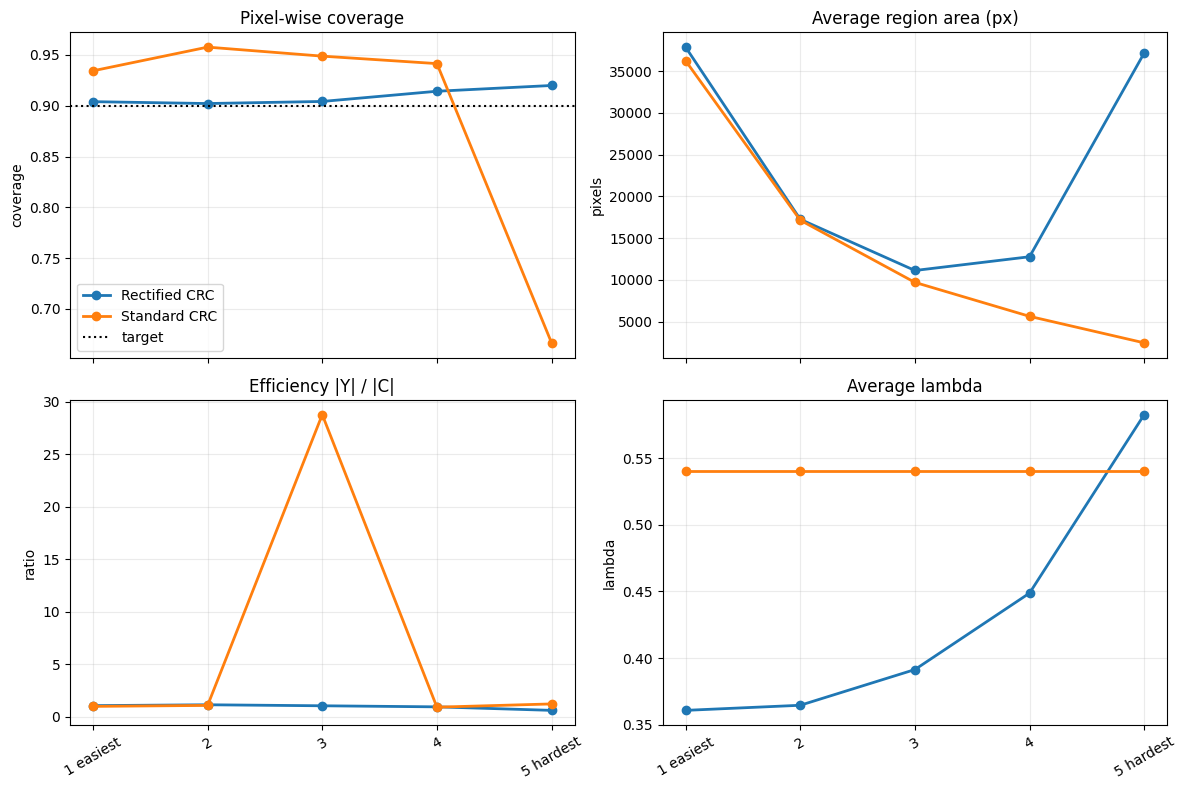

In [9]:
# Plot local behavior across each difficulty-bin definition.
for bin_type, bin_metrics in local_bin_metrics.groupby("bin_type", sort=False):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    plot_specs = [
        ("pixelwise_coverage", "Pixel-wise coverage", axs[0, 0]),
        ("region_area", "Average region area (px)", axs[0, 1]),
        ("efficiency_y_over_c", "Efficiency |Y| / |C|", axs[1, 0]),
        ("lambda_mean", "Average lambda", axs[1, 1]),
    ]

    for metric, title, ax in plot_specs:
        for method, df_method in bin_metrics.groupby("method", sort=False):
            ax.plot(
                df_method["difficulty_bin"].astype(str),
                df_method[metric],
                marker="o",
                linewidth=2,
                label=method,
            )
        if metric == "pixelwise_coverage":
            ax.axhline(1.0 - ALPHA, color="black", linestyle=":", linewidth=1.5, label="target")
        ax.set_title(title)
        ax.grid(alpha=0.25)
        ax.tick_params(axis="x", rotation=30)

    axs[0, 0].set_ylabel("coverage")
    axs[0, 1].set_ylabel("pixels")
    axs[1, 0].set_ylabel("ratio")
    axs[1, 1].set_ylabel("lambda")
    axs[0, 0].legend()
    fig.suptitle(f"Local behavior across {bin_type} bins", y=1.02)
    plt.tight_layout()
    plt.show()


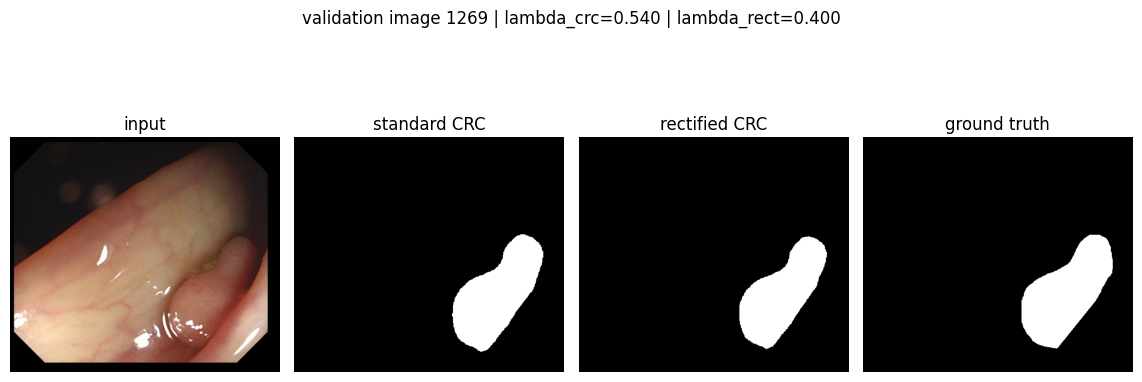

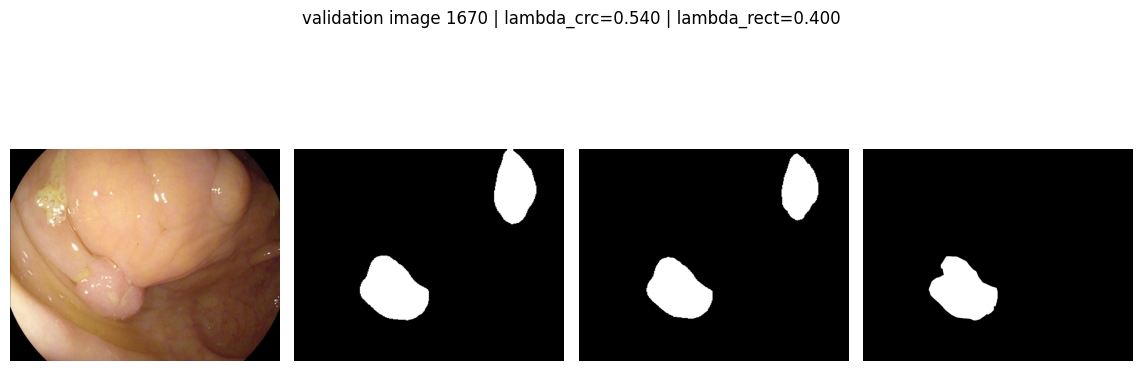

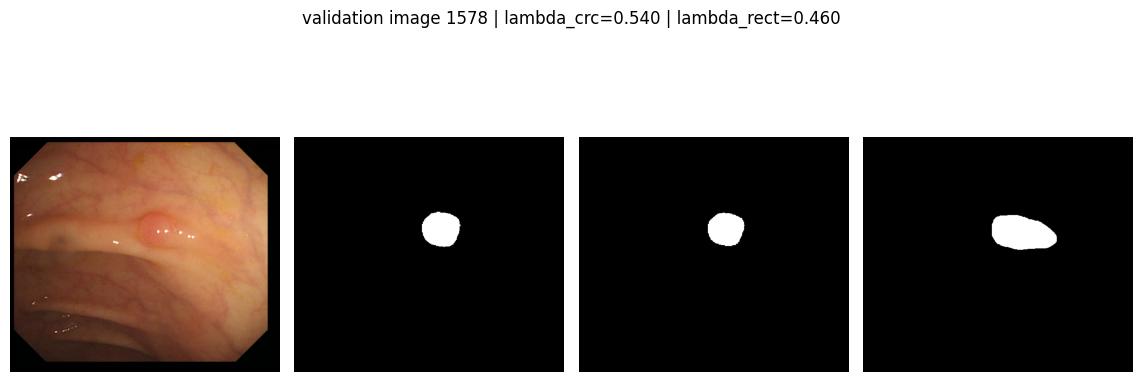

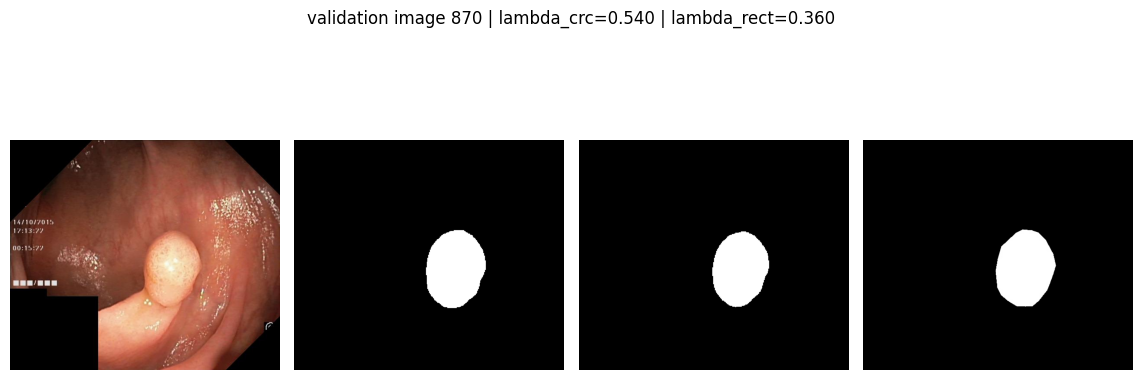

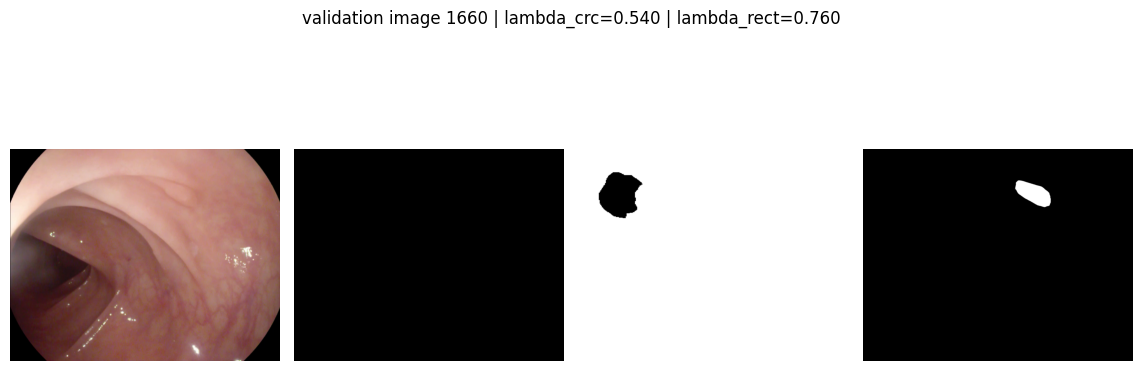

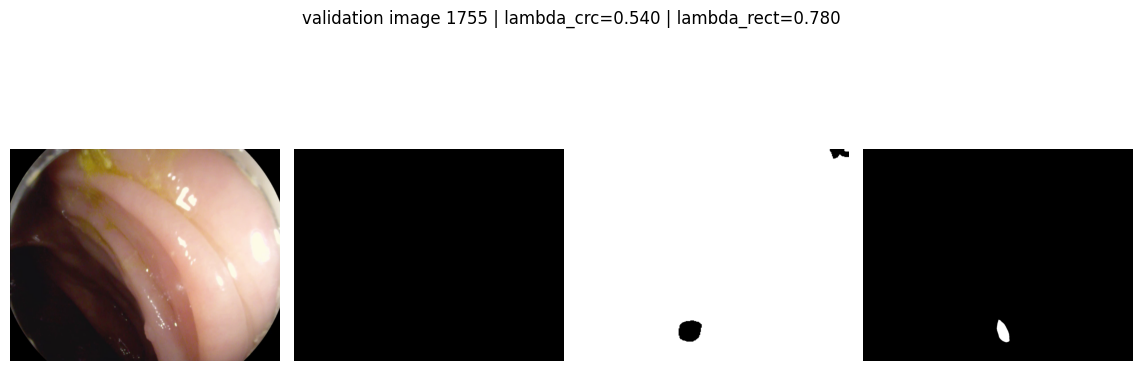

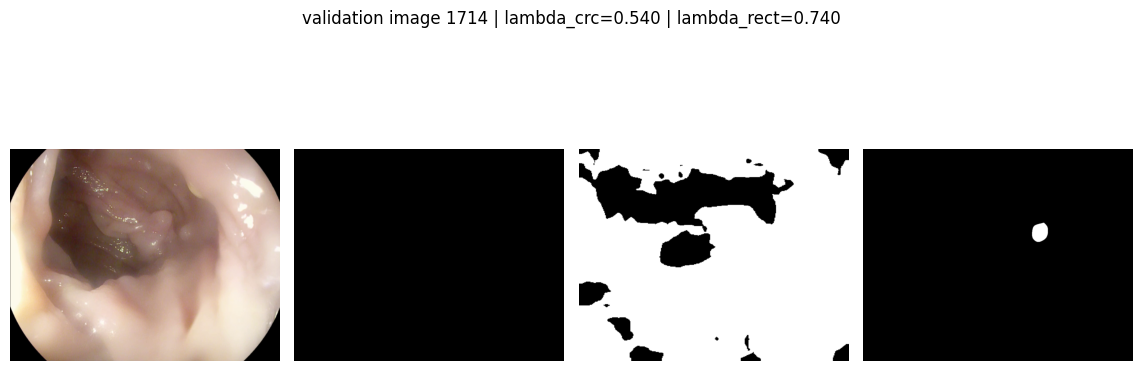

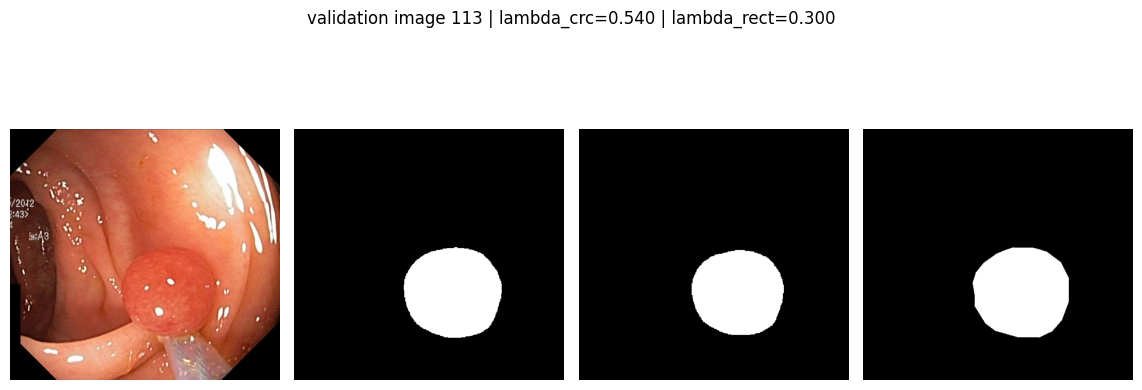

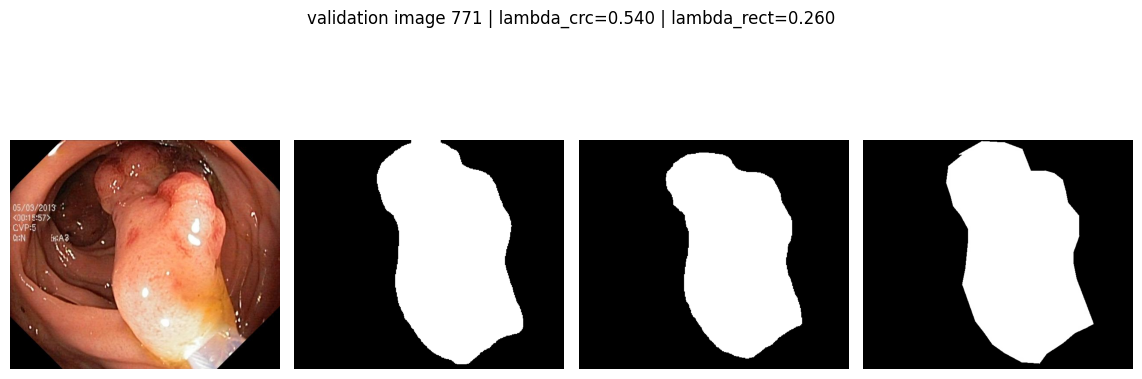

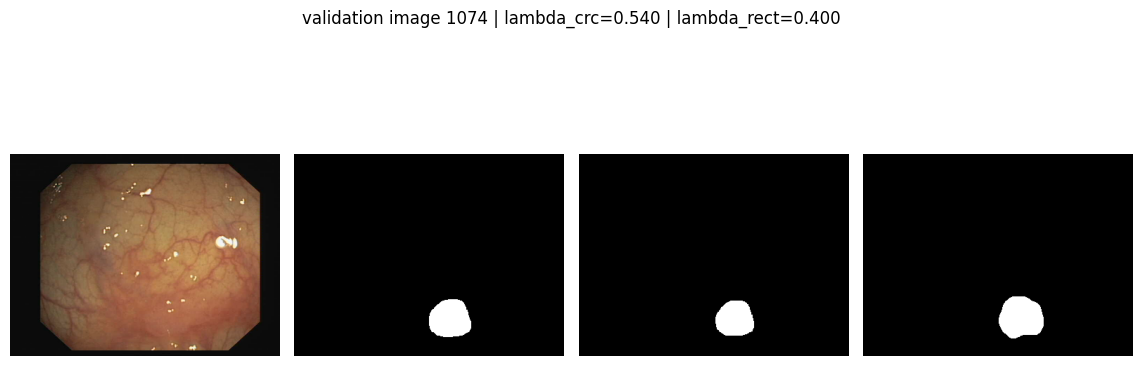

In [10]:
# Show validation examples with the global CRC mask and each image's rectified mask.
rng_examples = np.random.default_rng(4)
example_dir = data_dir / "polyps" / "examples"
validation_example_indexes = np.intersect1d(val_indexes, np.asarray(example_indexes, dtype=int))

if len(validation_example_indexes) == 0:
    raise ValueError("No validation images have cached example .jpg files for display.")

for i in range(min(10, len(validation_example_indexes))):
    rand_idx = int(rng_examples.choice(validation_example_indexes))
    val_pos = int(np.where(val_indexes == rand_idx)[0][0])
    lam_rect = lambda_by_image_index[rand_idx]

    img = imread(example_dir / f"{rand_idx}.jpg")
    gt_mask = imread(example_dir / f"{rand_idx}_gt_mask.jpg")

    standard_mask_352 = segmentation_mask(
        sgmd[rand_idx:rand_idx + 1],
        np.array([route2_out["standard_lambda"]]),
    )[0]
    rectified_mask_352 = route2_out["val_masks"][val_pos]

    standard_mask = resize(
        standard_mask_352.astype(float),
        (img.shape[0], img.shape[1]),
        order=0,
        anti_aliasing=False,
        preserve_range=True,
    ) > 0.5
    rectified_mask = resize(
        rectified_mask_352.astype(float),
        (img.shape[0], img.shape[1]),
        order=0,
        anti_aliasing=False,
        preserve_range=True,
    ) > 0.5

    fig, axs = plt.subplots(1, 4, figsize=(11.52, 4.76))
    axs[0].imshow(img)
    axs[0].axis("off")
    axs[1].imshow(standard_mask, cmap="gray")
    axs[1].axis("off")
    axs[2].imshow(rectified_mask, cmap="gray")
    axs[2].axis("off")
    axs[3].imshow(gt_mask, cmap="gray")
    axs[3].axis("off")

    if i == 0:
        axs[0].set_title("input")
        axs[1].set_title("standard CRC")
        axs[2].set_title("rectified CRC")
        axs[3].set_title("ground truth")

    fig.suptitle(
        f"validation image {rand_idx} | "
        f"lambda_crc={route2_out['standard_lambda']:.3f} | "
        f"lambda_rect={lam_rect:.3f}"
    )
    plt.tight_layout()
    plt.show()


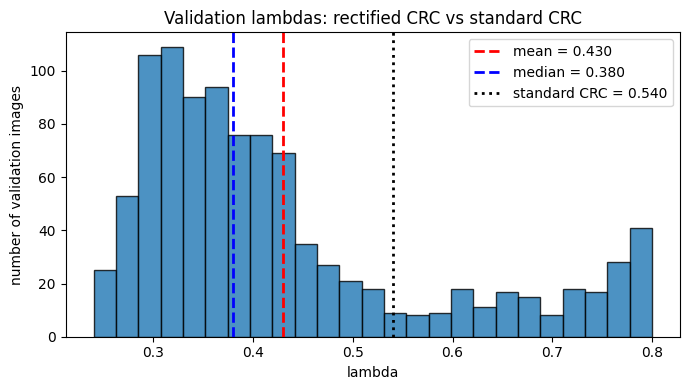

count    998.000000
mean       0.429679
std        0.149026
min        0.240000
25%        0.320000
50%        0.380000
75%        0.480000
max        0.800000
Name: rectified_validation_lambda, dtype: float64

In [15]:
lambda_values = route2_out["lambda_val"]

plt.figure(figsize=(7, 4))
plt.hist(lambda_values, bins=25, edgecolor="black", alpha=0.8)
plt.axvline(lambda_values.mean(), color="red", linestyle="--", linewidth=2, label=f"mean = {lambda_values.mean():.3f}")
plt.axvline(np.median(lambda_values), color="blue", linestyle="--", linewidth=2, label=f"median = {np.median(lambda_values):.3f}")
plt.axvline(route2_out["standard_lambda"], color="black", linestyle=":", linewidth=2, label=f"standard CRC = {route2_out['standard_lambda']:.3f}")

plt.xlabel("lambda")
plt.ylabel("number of validation images")
plt.title("Validation lambdas: rectified CRC vs standard CRC")
plt.legend()
plt.tight_layout()
plt.show()

pd.Series(lambda_values, name="rectified_validation_lambda").describe()
